In [1]:
"""
分析深度学习特征的构造方式和有效性：请严格遵守steps，注意我用的是第二版pPred.exe
    使用pFind（without pPred）鉴定结果的<0.001的target进行微调，查看>0.001的target和decoy的cosine similarity和RT difference的分布
        - 从鉴定结果pFind-Filtered.spectra中筛选q_value<0.001的target进行微调，得到finetuned_ms2.pt、finetuned_rt.pt
"""
import os
from utils import *

In [2]:
"""
step1: meta information
"""
work_dir = "data/dl_astral/"  # 工作目录，存储构造的训练数据、微调好的模型等
ms_dir = "D:/workspace/data/ms/Astral/top50/"
res_dir = "D:/workspace/pFindWorkspace/Astral/top50-restricted/result/"  # pFind without pPred
topk = 5000  # /5000
ppm = 10
# work_dir = "data/dl_exo/"  # 工作目录，存储构造的训练数据、微调好的模型等
# ms_dir = "D:/workspace/data/ms/normal/human_exo/"
# res_dir = "D:/workspace/pFindWorkspace/normal/human_exo/new-restricted/result/"  # pFind without pPred
# topk = 200  # /5000
# ppm = 20

mgf_paths = [os.path.join(ms_dir,filename) for filename in os.listdir(ms_dir) if filename.endswith(".mgf")]

In [228]:
"""
step 2: 
    (1) 从鉴定结果pFind.spectra中筛选q_value<=0.001的target，(2)构造训练数据
    (1) 从鉴定结果pFind.spectra中筛选q_value<=0.01的target，作为正例；q_value<=0.5的decoy用作负例，(2)构造实验数据，构造待预测数据
"""
spec2fp = dict()  # spectrum name -> finetuned peptide
fps = set()  # finetuned peptides
spec2pp = dict()
pps = set()
spec2np = dict()
nps = set()

print("collect finetuned peptides...")
fr = open(os.path.join(res_dir,"pFind.spectra"),"r")
next(fr,None)
for line in fr:
    items = line.strip().split("\t")
    q_value = float(items[4])
    if q_value >= 512:
        break
    spectrum_name = items[0]
    charge = int(items[3])
    seq,mod = items[5],items[10]
    modified_seq = seq+"\t"+mod
    decoy = (items[15]=="decoy")
    if q_value<=0.001 and not decoy and modified_seq not in fps:  # 若肽段重复，则选最佳PSM
        spec2fp[spectrum_name] = modified_seq
        fps.add(modified_seq)
    elif 0.001<q_value<=0.01 and not decoy and modified_seq not in pps and modified_seq not in fps:
        spec2pp[spectrum_name] = modified_seq
        pps.add(modified_seq)
    elif q_value<=0.5 and decoy:
        spec2np[spectrum_name] = modified_seq
        nps.add(modified_seq)
fr.close()
print(f"Complete! Finetuned peptides:{len(fps)},Positive peptides:{len(pps)},Negative peptides:{len(nps)}")


element2mass = get_element2mass("infos/element.ini")
aa2mass = get_aa2mass("infos/aa.ini", element2mass)
mod2mass = get_mod2mass("infos/modification.ini")
# 构造ms2和rt的训练数据, 正负例的实验数据
rt_min,rt_max=1e10,-1
chg_min,chg_max=1e10,-1
f_ms2_ft = open(os.path.join(work_dir,"train_data.ms2data"),"w")
f_ms2_ft.write("head\n")
f_ms2_pos = open(os.path.join(work_dir,"exp_data.positive.ms2data"),"w")
f_ms2_pos.write("head\n")
f_ms2_neg = open(os.path.join(work_dir,"exp_data.negative.ms2data"),"w")
f_ms2_neg.write("head\n")
f_rt_ft = open(os.path.join(work_dir,"train_data.rtdata"),"w")
f_rt_ft.write("seq\tmod\trt\n")
f_rt_pos = open(os.path.join(work_dir,"exp_data.positive.rtdata"),"w")
f_rt_pos.write("seq\tmod\trt\n")
f_rt_neg = open(os.path.join(work_dir,"exp_data.negative.rtdata"),"w")
f_rt_neg.write("seq\tmod\trt\n")
f_pep_pos = open(os.path.join(work_dir,"pred_data.positive.pepdata"),"w")
f_pep_pos.write("head\n")
f_pep_neg = open(os.path.join(work_dir,"pred_data.negative.pepdata"),"w")
f_pep_neg.write("head\n")
cnt,matched_cnt = 0,0
for mgf_path in mgf_paths:
    print(mgf_path)
    fr = open(mgf_path,"r")
    while True:
        line = fr.readline()
        if not line:
            break
        if line.startswith("C"):  # CHARGE=
            precursor_charge = int(line[7:].strip("+\n"))  # 3+
            chg_min = min(chg_min,precursor_charge)
            chg_max = max(chg_max,precursor_charge)
        elif line.startswith("T"):  # TITLE=
            spectrum_name = line[6:].strip()
            cnt += 1
            if cnt % 10000 == 0:
                print(cnt, matched_cnt)
        elif line.startswith("P"):  # PEPMASS=
            mz = float(line[8:].strip())
        elif line.startswith("R"):
            rt = float(line[12:].strip())  # RTINSECONDS=
            rt_min = min(rt_min,rt)
            rt_max = max(rt_max,rt)
        elif "A" <= line[0] <= "Z":
            continue
        else:  # PEAKS
            ft,pos,neg=False,False,False
            if spectrum_name in spec2fp.keys():
                ft = True
                modified_seq = spec2fp[spectrum_name]
            elif spectrum_name in spec2pp.keys():
                pos = True
                modified_seq = spec2pp[spectrum_name]
            elif spectrum_name in spec2np.keys():
                neg = True
                modified_seq = spec2np[spectrum_name]
            else:  # 不解析
                while True:
                    line = fr.readline()
                    if line.startswith("E"):
                        break
                continue

            matched_cnt += 1
            peaks = list()
            while True:
                items = line.strip().split()
                mz,intensity = float(items[0]),float(items[1])
                peaks.append((mz, intensity))
                line = fr.readline()
                if line.startswith("E"):
                    break

            
            matched = cal_by_match(peaks, modified_seq, precursor_charge, aa2mass, mod2mass, topk=topk, ppm=ppm)
            if len(matched) == 0:
                print("error!")
                continue
            matched = sorted(matched, key=lambda m:m[2], reverse=True)  # 按matched_intensity从大到小排序
            max_intensity = matched[0][2]
            s_ms2 = f"{modified_seq}\t{precursor_charge}\t{len(matched)}\t"
            for ion_name,mz,intensity,error in matched:
                ion_id = (ion_name.count('+')-1)*2
                ion_pos = int(ion_name[1:ion_name.index('+')])-1  # b1:0
                if ion_name[0] == 'y':
                    ion_id += 1
                    ion_pos = len(modified_seq.split("\t")[0])-2-ion_pos
                s_ms2 += f"{ion_id}\t{ion_pos}\t{intensity/max_intensity}\t"

            if ft:
                f_ms2_ft.write(s_ms2+"\n")
                f_rt_ft.write(f"{modified_seq}\t{rt/60.0}\n")
            elif pos:
                f_ms2_pos.write(s_ms2+"\n")
                f_rt_pos.write(f"{modified_seq}\t{rt/60.0}\n")
                f_pep_pos.write(f"{modified_seq}\t\t\t\t{1<<precursor_charge}\n")
            else:
                f_ms2_neg.write(s_ms2+"\n")
                f_rt_neg.write(f"{modified_seq}\t{rt/60.0}\n")    
                f_pep_neg.write(f"{modified_seq}\t\t\t\t{1<<precursor_charge}\n")
    fr.close()
f_ms2_ft.close()
f_ms2_pos.close()
f_ms2_neg.close()
f_rt_ft.close()
f_rt_pos.close()
f_rt_neg.close()
f_pep_pos.close()
f_pep_neg.close()
print(f"rt_max:{rt_max/60.0},rt_min:{rt_min/60.0}")
print(f"charge_max:{chg_max},charge_min:{chg_min}")

collect finetuned peptides...
Complete! Finetuned peptides:32014,Positive peptides:9494,Negative peptides:27434
D:/workspace/data/ms/Astral/top50/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_01_20230808155512_HCDAST.mgf
10000 587
20000 1275
30000 1987
40000 2659
50000 3305
60000 4012
70000 4761
80000 5440
90000 6175
100000 6889
110000 7584
120000 8332
130000 9139
140000 9935
150000 10709
160000 11527
170000 12392
180000 13197
190000 13996
200000 14824
210000 15642
220000 16484
230000 17315
240000 18153
250000 18995
260000 19923
270000 20815
280000 21690
290000 22610
300000 23688
310000 24937
320000 26223
330000 27532
340000 28834
350000 30098
360000 31346
370000 32455
380000 33529
390000 34439
400000 35432
D:/workspace/data/ms/Astral/top50/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_02_20230808161140_HCDAST.mgf
410000 35886
420000 36273
430000 36690
440000 37092
450000 37495
460000 37906
470000 38305
480000 38692
490000 39085
500000 39449
510000 39833
520000 40216
530000

In [13]:
"""
step3: 微调，得到finetuned_ms2.pt、finetuned_rt.pt
    pPred.exe -rt --tune -m pPredRT_main.pt -n finetuned -om D:\projects\pythonProjects\tools\data\dl_astral\ -d D:\projects\pythonProjects\tools\data\dl_astral\train_data.rtdata -i 0.05356_13.95375 -l D:\projects\pythonProjects\tools\data\dl_astral\log.txt -bs 1024
    pPred.exe -ms2 --tune -m pPredMS2_main.pt -n finetuned -om D:\projects\pythonProjects\tools\data\dl_astral\ -d D:\projects\pythonProjects\tools\data\dl_astral\train_data.ms2data -i 1_28_28_28 -l D:\projects\pythonProjects\tools\data\dl_astral\log.txt -bs 1024
"""

2 0
1 0
4 4


In [ ]:
"""
step4: 预测
positive:
	pPred.exe -rt --pred -m D:\projects\pythonProjects\tools\data\dl_astral\finetuned_rt.pt -d D:\projects\pythonProjects\tools\data\dl_astral\pred_data.positive.pepdata -op D:\projects\pythonProjects\tools\data\dl_astral\pred_data.positive.rtdata -i 0.05356_13.95375 -l D:\projects\pythonProjects\tools\data\dl_astral\log.txt -bs 1024
	pPred.exe -ms2 --pred -m D:\projects\pythonProjects\tools\data\dl_astral\finetuned_ms2.pt -d D:\projects\pythonProjects\tools\data\dl_astral\pred_data.positive.pepdata -op D:\projects\pythonProjects\tools\data\dl_astral\pred_data.positive.ms2data -i 1_28_28_28_2_6 -l D:\projects\pythonProjects\tools\data\dl_astral\log.txt -bs 1024
negative:
	pPred.exe -rt --pred -m D:\projects\pythonProjects\tools\data\dl_astral\finetuned_rt.pt -d D:\projects\pythonProjects\tools\data\dl_astral\pred_data.negative.pepdata -op D:\projects\pythonProjects\tools\data\dl_astral\pred_data.negative.rtdata -i 0.05356_13.95375 -l D:\projects\pythonProjects\tools\data\dl_astral\log.txt -bs 1024
	pPred.exe -ms2 --pred -m D:\projects\pythonProjects\tools\data\dl_astral\finetuned_ms2.pt -d D:\projects\pythonProjects\tools\data\dl_astral\pred_data.negative.pepdata -op D:\projects\pythonProjects\tools\data\dl_astral\pred_data.negative.ms2data -i 1_28_28_28_2_6 -l D:\projects\pythonProjects\tools\data\dl_astral\log.txt -bs 1024
"""

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution(ax, data, plot_type='frequency', bins=10, label='positive', save_path=None):
    """
    绘制浮点数列表的分布图
    
    参数:
    data (list): 包含浮点数的列表
    plot_type (str): 图表类型，可选'histogram'（直方图）或'kde'（核密度估计图）
    bins (int): 直方图的分箱数量
    title (str): 图表标题，默认为None（自动生成标题）
    save_path (str): 图表保存路径，默认为None（不保存）
    
    返回:
    fig, ax: matplotlib的图表和轴对象
    """
    data_array = np.array(data)
    
    # 根据指定类型绘制分布图
    if plot_type == 'frequency':
        ax.hist(data_array, bins=bins, alpha=0.7, edgecolor='black', label=label)
        ax.set_ylabel('Frequency')
    elif plot_type == 'density':
        ax.hist(data_array, bins=bins, alpha=0.7, edgecolor='black', label=label, density=True)
        ax.set_ylabel('Density')
    elif plot_type == 'kde':
        sns.kdeplot(data_array, ax=ax, label=label, fill=True)
        ax.set_ylabel('Density')
    
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # 保存图表（如果指定了路径）
    if save_path:
        plt.tight_layout()
        plt.savefig(save_path)

Text(0.5, 1.0, 'Distribution of positive/negative {exp_rt-pred_rt}')

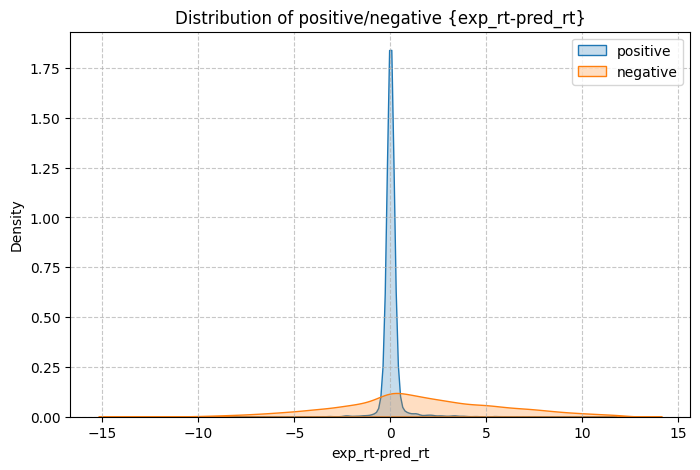

In [13]:
"""
step5: 绘制正负例在所构造深度学习特征上的分布(可用于验证特征的有效性、也可用于观察并调整特征的设计方式)
    finetuned RT model
"""
pos_rts = list()  # exp_rt - pred_rt
neg_rts = list()

# positive data
fw_exp = open(os.path.join(work_dir,"exp_data.positive.rtdata"),"r")
next(fw_exp,None)
fw_pred = open(os.path.join(work_dir,"pred_data.positive.rtdata"),"r")
next(fw_pred,None)
for exp_line in fw_exp:
    pred_line = fw_pred.readline()
    exp_rt = float(exp_line.strip().split("\t")[-1])
    pred_rt = float(pred_line.strip())
    pos_rts.append((exp_rt-pred_rt))
fw_exp.close()
fw_pred.close()
    
# negative data
fw_exp = open(os.path.join(work_dir,"exp_data.negative.rtdata"),"r")
next(fw_exp,None)
fw_pred = open(os.path.join(work_dir,"pred_data.negative.rtdata"),"r")
next(fw_pred,None)
for exp_line in fw_exp:
    pred_line = fw_pred.readline()
    exp_rt = float(exp_line.strip().split("\t")[-1])
    pred_rt = float(pred_line.strip())
    neg_rts.append(exp_rt-pred_rt)
fw_exp.close()
fw_pred.close()

fig, ax = plt.subplots(figsize=(8, 5))
plot_distribution(ax, pos_rts, plot_type='kde', bins=100, label='positive')
plot_distribution(ax, neg_rts, plot_type='kde', bins=100, label='negative')
ax.set_xlabel('exp_rt-pred_rt')
ax.legend()
ax.set_title('Distribution of positive/negative {exp_rt-pred_rt}')

Text(0.5, 1.0, 'Distribution of positive/negative {exp_rt-pred_rt}')

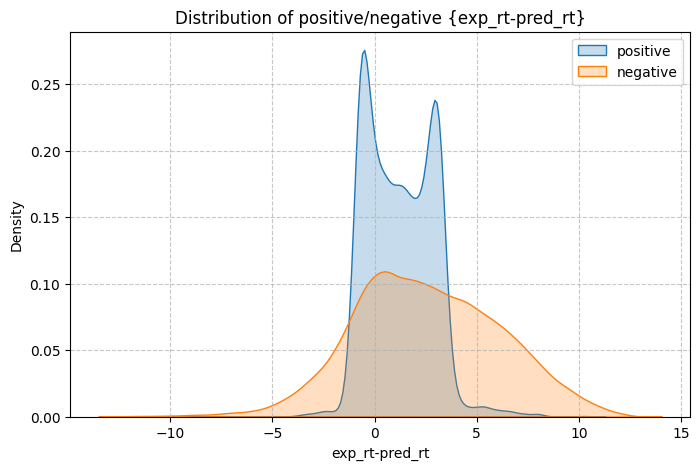

In [240]:
"""
step5: 绘制正负例在所构造深度学习特征上的分布(可用于验证特征的有效性、也可用于观察并调整特征的设计方式)
    original RT model
"""
pos_rts = list()  # exp_rt - pred_rt
neg_rts = list()

# positive data
fw_exp = open(os.path.join(work_dir,"exp_data.positive.rtdata"),"r")
next(fw_exp,None)
fw_pred = open(os.path.join(work_dir,"pred_data.positive.rtdata"),"r")
next(fw_pred,None)
for exp_line in fw_exp:
    pred_line = fw_pred.readline()
    exp_rt = float(exp_line.strip().split("\t")[-1])
    pred_rt = float(pred_line.strip())
    pos_rts.append((exp_rt-pred_rt))
fw_exp.close()
fw_pred.close()
    
# negative data
fw_exp = open(os.path.join(work_dir,"exp_data.negative.rtdata"),"r")
next(fw_exp,None)
fw_pred = open(os.path.join(work_dir,"pred_data.negative.rtdata"),"r")
next(fw_pred,None)
for exp_line in fw_exp:
    pred_line = fw_pred.readline()
    exp_rt = float(exp_line.strip().split("\t")[-1])
    pred_rt = float(pred_line.strip())
    neg_rts.append(exp_rt-pred_rt)
fw_exp.close()
fw_pred.close()

fig, ax = plt.subplots(figsize=(8, 5))
plot_distribution(ax, pos_rts, plot_type='kde', bins=100, label='positive')
plot_distribution(ax, neg_rts, plot_type='kde', bins=100, label='negative')
ax.set_xlabel('exp_rt-pred_rt')
ax.legend()
ax.set_title('Distribution of positive/negative {exp_rt-pred_rt}')

### 结论：
#### 1. RT模型建议微调，否则效果不好
#### 2. RT特征建议做成abs(exp_rt-pred_rt)格式
#### 3. RT特征确实可有效区分正负例

Text(0.5, 1.0, 'Distribution of positive/negative cosine similarity')

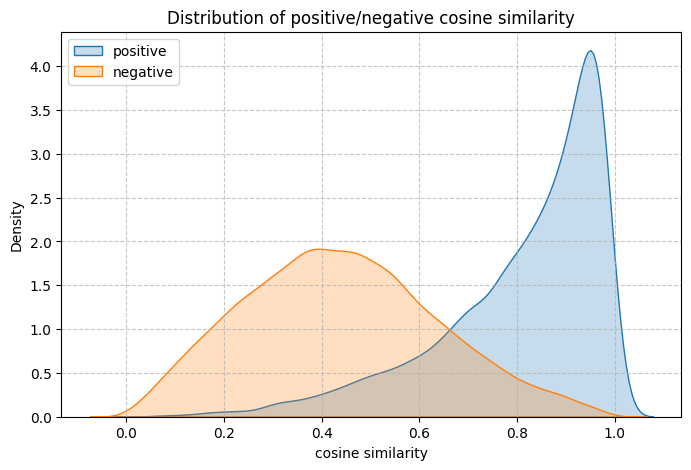

In [14]:
"""
step5: 绘制正负例在所构造深度学习特征上的分布(可用于验证特征的有效性、也可用于观察并调整特征的设计方式)
    finetuned MS2 model
"""
pos_ms2s = list()  # cosine similarity
neg_ms2s = list()

# positive data
fw_exp = open(os.path.join(work_dir,"exp_data.positive.ms2data"),"r")
next(fw_exp,None)
fw_pred = open(os.path.join(work_dir,"pred_data.positive.ms2data"),"r")
next(fw_pred,None)
for exp_line in fw_exp:
    exp_items = exp_line.strip().split("\t")
    modified_seq = exp_items[0]+"\t"+exp_items[1]
    charge = int(exp_items[2])
    n = len(exp_items[0])-1  # seq_len-1
    exp_vec = np.zeros(n*charge*2)
    for i in range(int(exp_items[3])):
        ion_type,pos,intensity = int(exp_items[4+3*i]),int(exp_items[5+3*i]),float(exp_items[6+3*i])
        exp_vec[ion_type*n+pos] = intensity

    pred_vec = np.zeros(n*charge*2)
    pred_line = fw_pred.readline()
    pred_items = pred_line.strip().split("\t")
    start_pos = charge*2
    for i in range(int(pred_items[start_pos-1])):
        ion_type,pos,intensity = int(pred_items[start_pos+3*i]),int(pred_items[start_pos+3*i+1]),float(pred_items[start_pos+3*i+2])
        pred_vec[ion_type*n+pos] = intensity
    
    # pos_ms2s.append(np.corrcoef(exp_vec,pred_vec)[0,1])  # Pearson
    pos_ms2s.append(np.dot(exp_vec,pred_vec)/(np.linalg.norm(exp_vec)*np.linalg.norm(pred_vec)))  # cosine
fw_exp.close()
fw_pred.close()
    
# negative data
fw_exp = open(os.path.join(work_dir,"exp_data.negative.ms2data"),"r")
next(fw_exp,None)
fw_pred = open(os.path.join(work_dir,"pred_data.negative.ms2data"),"r")
next(fw_pred,None)
for exp_line in fw_exp:
    exp_items = exp_line.strip().split("\t")
    modified_seq = exp_items[0]+"\t"+exp_items[1]
    charge = int(exp_items[2])
    n = len(exp_items[0])-1  # seq_len-1
    exp_vec = np.zeros(n*charge*2)
    for i in range(int(exp_items[3])):
        ion_type,pos,intensity = int(exp_items[4+3*i]),int(exp_items[5+3*i]),float(exp_items[6+3*i])
        exp_vec[ion_type*n+pos] = intensity

    pred_vec = np.zeros(n*charge*2)
    pred_line = fw_pred.readline()
    pred_items = pred_line.strip().split("\t")
    start_pos = charge*2
    for i in range(int(pred_items[start_pos-1])):
        ion_type,pos,intensity = int(pred_items[start_pos+3*i]),int(pred_items[start_pos+3*i+1]),float(pred_items[start_pos+3*i+2])
        pred_vec[ion_type*n+pos] = intensity
    
    # neg_ms2s.append(np.corrcoef(exp_vec,pred_vec)[0,1])  # Pearson
    neg_ms2s.append(np.dot(exp_vec,pred_vec)/(np.linalg.norm(exp_vec)*np.linalg.norm(pred_vec)))  # cosine
fw_exp.close()
fw_pred.close()

fig, ax = plt.subplots(figsize=(8, 5))
plot_distribution(ax, pos_ms2s, plot_type='kde', bins=100, label='positive')
plot_distribution(ax, neg_ms2s, plot_type='kde', bins=100, label='negative')
ax.set_xlabel('cosine similarity')
ax.legend()
ax.set_title('Distribution of positive/negative cosine similarity')

Text(0.5, 1.0, 'Distribution of positive/negative cosine similarity')

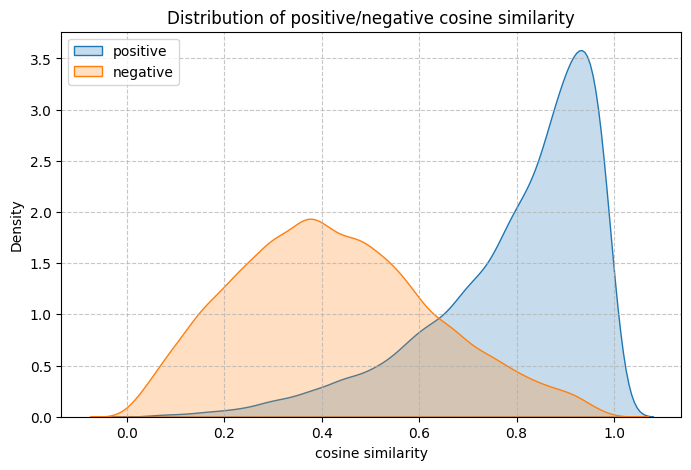

In [243]:
"""
step5: 绘制正负例在所构造深度学习特征上的分布(可用于验证特征的有效性、也可用于观察并调整特征的设计方式)
    original MS2 model
"""
pos_ms2s = list()  # cosine similarity
neg_ms2s = list()

# positive data
fw_exp = open(os.path.join(work_dir,"exp_data.positive.ms2data"),"r")
next(fw_exp,None)
fw_pred = open(os.path.join(work_dir,"pred_data.positive.ms2data"),"r")
next(fw_pred,None)
for exp_line in fw_exp:
    exp_items = exp_line.strip().split("\t")
    modified_seq = exp_items[0]+"\t"+exp_items[1]
    charge = int(exp_items[2])
    n = len(exp_items[0])-1  # seq_len-1
    exp_vec = np.zeros(n*charge*2)
    for i in range(int(exp_items[3])):
        ion_type,pos,intensity = int(exp_items[4+3*i]),int(exp_items[5+3*i]),float(exp_items[6+3*i])
        exp_vec[ion_type*n+pos] = intensity

    pred_vec = np.zeros(n*charge*2)
    pred_line = fw_pred.readline()
    pred_items = pred_line.strip().split("\t")
    start_pos = charge*2
    for i in range(int(pred_items[start_pos-1])):
        ion_type,pos,intensity = int(pred_items[start_pos+3*i]),int(pred_items[start_pos+3*i+1]),float(pred_items[start_pos+3*i+2])
        pred_vec[ion_type*n+pos] = intensity
    
    # pos_ms2s.append(np.corrcoef(exp_vec,pred_vec)[0,1])  # Pearson
    pos_ms2s.append(np.dot(exp_vec,pred_vec)/(np.linalg.norm(exp_vec)*np.linalg.norm(pred_vec)))  # cosine
fw_exp.close()
fw_pred.close()
    
# negative data
fw_exp = open(os.path.join(work_dir,"exp_data.negative.ms2data"),"r")
next(fw_exp,None)
fw_pred = open(os.path.join(work_dir,"pred_data.negative.ms2data"),"r")
next(fw_pred,None)
for exp_line in fw_exp:
    exp_items = exp_line.strip().split("\t")
    modified_seq = exp_items[0]+"\t"+exp_items[1]
    charge = int(exp_items[2])
    n = len(exp_items[0])-1  # seq_len-1
    exp_vec = np.zeros(n*charge*2)
    for i in range(int(exp_items[3])):
        ion_type,pos,intensity = int(exp_items[4+3*i]),int(exp_items[5+3*i]),float(exp_items[6+3*i])
        exp_vec[ion_type*n+pos] = intensity

    pred_vec = np.zeros(n*charge*2)
    pred_line = fw_pred.readline()
    pred_items = pred_line.strip().split("\t")
    start_pos = charge*2
    for i in range(int(pred_items[start_pos-1])):
        ion_type,pos,intensity = int(pred_items[start_pos+3*i]),int(pred_items[start_pos+3*i+1]),float(pred_items[start_pos+3*i+2])
        pred_vec[ion_type*n+pos] = intensity
    
    # neg_ms2s.append(np.corrcoef(exp_vec,pred_vec)[0,1])  # Pearson
    neg_ms2s.append(np.dot(exp_vec,pred_vec)/(np.linalg.norm(exp_vec)*np.linalg.norm(pred_vec)))  # cosine
fw_exp.close()
fw_pred.close()

fig, ax = plt.subplots(figsize=(8, 5))
plot_distribution(ax, pos_ms2s, plot_type='kde', bins=100, label='positive')
plot_distribution(ax, neg_ms2s, plot_type='kde', bins=100, label='negative')
ax.set_xlabel('cosine similarity')
ax.legend()
ax.set_title('Distribution of positive/negative cosine similarity')

### 结论：
#### 1. MS2模型似乎不微调效果也不错（可能目前谱峰没有预处理？）
#### 2. MS2的cosine similarity特征可以有效区分正负例

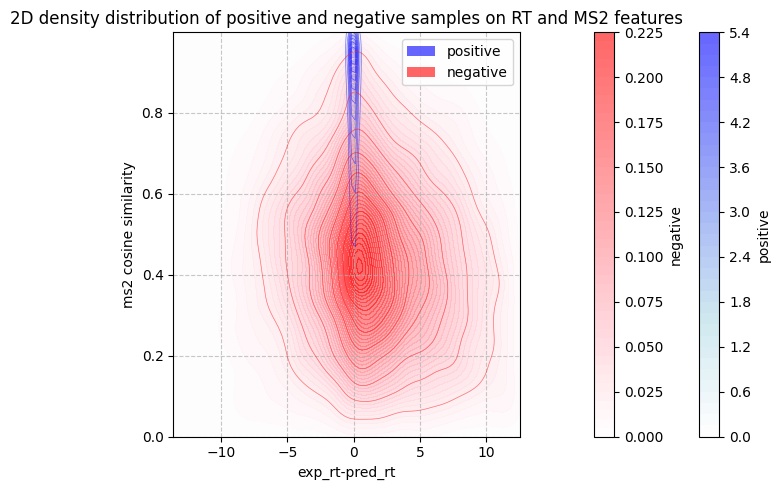

In [15]:
"""
2D: finetuned RT & MS2 model
"""
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt

# 计算二维核密度估计
def calculate_kde(x, y):
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    return kde

# 创建画布
fig, axis = plt.subplots(figsize=(7, 5))

# 确定绘图范围
x_min = min(min(pos_rts), min(neg_rts))
x_max = max(max(pos_rts), max(neg_rts))
y_min = min(min(pos_ms2s), min(neg_ms2s))
y_max = max(max(pos_ms2s), max(neg_ms2s))

# 创建网格
x_grid, y_grid = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([x_grid.ravel(), y_grid.ravel()])

# 正样本二维密度图
pos_kde = calculate_kde(pos_rts, pos_ms2s)
pos_density = np.reshape(pos_kde(positions).T, x_grid.shape)

# 负样本二维密度图
neg_kde = calculate_kde(neg_rts, neg_ms2s)
neg_density = np.reshape(neg_kde(positions).T, x_grid.shape)

# 自定义蓝色调色板 (正样本)
blue_cmap = LinearSegmentedColormap.from_list('custom_blue', [(0, 'white'), (0.3, '#add8e6'), (1, 'blue')])
# 自定义红色调色板 (负样本)
red_cmap = LinearSegmentedColormap.from_list('custom_red', [(0, 'white'), (0.3, '#ffb6c1'), (1, 'red')])

# 绘制正样本密度图
contour_pos = axis.contourf(x_grid, y_grid, pos_density, levels=50, cmap=blue_cmap, alpha=0.6)
# 绘制负样本密度图
contour_neg = axis.contourf(x_grid, y_grid, neg_density, levels=50, cmap=red_cmap, alpha=0.6)

# 添加等高线边缘，增强区分度
axis.contour(x_grid, y_grid, pos_density, levels=10, colors='blue', alpha=0.5, linewidths=0.5)
axis.contour(x_grid, y_grid, neg_density, levels=10, colors='red', alpha=0.5, linewidths=0.5)

# 添加图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.6, label='positive'),
                   Patch(facecolor='red', alpha=0.6, label='negative')]
axis.legend(handles=legend_elements, loc='upper right')

# 设置坐标轴标签和标题
axis.set_xlabel('exp_rt-pred_rt')
axis.set_ylabel('ms2 cosine similarity')
axis.set_title('2D density distribution of positive and negative samples on RT and MS2 features')

# 添加网格线
axis.grid(True, linestyle='--', alpha=0.7)

# 添加颜色条
cbar_pos = plt.colorbar(contour_pos, ax=axis, pad=0.05)
cbar_pos.set_label('positive')
cbar_neg = plt.colorbar(contour_neg, ax=axis, pad=0.15)
cbar_neg.set_label('negative')

# 调整布局
plt.tight_layout()
plt.savefig('rt_ms2_feature_distribution_combined.png', dpi=300, bbox_inches='tight')
plt.show()

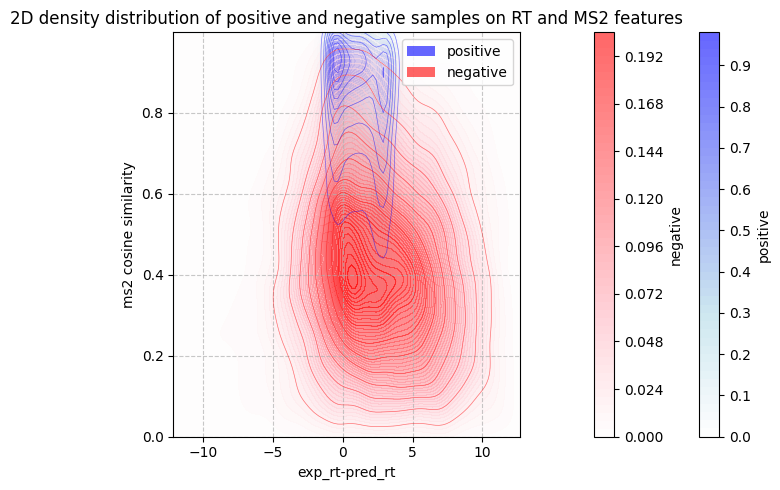

In [12]:
"""
2D: original RT & MS2 model
"""
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt

# 计算二维核密度估计
def calculate_kde(x, y):
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    return kde

# 创建画布
fig, axis = plt.subplots(figsize=(7, 5))

# 确定绘图范围
x_min = min(min(pos_rts), min(neg_rts))
x_max = max(max(pos_rts), max(neg_rts))
y_min = min(min(pos_ms2s), min(neg_ms2s))
y_max = max(max(pos_ms2s), max(neg_ms2s))

# 创建网格
x_grid, y_grid = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([x_grid.ravel(), y_grid.ravel()])

# 正样本二维密度图
pos_kde = calculate_kde(pos_rts, pos_ms2s)
pos_density = np.reshape(pos_kde(positions).T, x_grid.shape)

# 负样本二维密度图
neg_kde = calculate_kde(neg_rts, neg_ms2s)
neg_density = np.reshape(neg_kde(positions).T, x_grid.shape)

# 自定义蓝色调色板 (正样本)
blue_cmap = LinearSegmentedColormap.from_list('custom_blue', [(0, 'white'), (0.3, '#add8e6'), (1, 'blue')])
# 自定义红色调色板 (负样本)
red_cmap = LinearSegmentedColormap.from_list('custom_red', [(0, 'white'), (0.3, '#ffb6c1'), (1, 'red')])

# 绘制正样本密度图
contour_pos = axis.contourf(x_grid, y_grid, pos_density, levels=50, cmap=blue_cmap, alpha=0.6)
# 绘制负样本密度图
contour_neg = axis.contourf(x_grid, y_grid, neg_density, levels=50, cmap=red_cmap, alpha=0.6)

# 添加等高线边缘，增强区分度
axis.contour(x_grid, y_grid, pos_density, levels=10, colors='blue', alpha=0.5, linewidths=0.5)
axis.contour(x_grid, y_grid, neg_density, levels=10, colors='red', alpha=0.5, linewidths=0.5)

# 添加图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.6, label='positive'),
                   Patch(facecolor='red', alpha=0.6, label='negative')]
axis.legend(handles=legend_elements, loc='upper right')

# 设置坐标轴标签和标题
axis.set_xlabel('exp_rt-pred_rt')
axis.set_ylabel('ms2 cosine similarity')
axis.set_title('2D density distribution of positive and negative samples on RT and MS2 features')

# 添加网格线
axis.grid(True, linestyle='--', alpha=0.7)

# 添加颜色条
cbar_pos = plt.colorbar(contour_pos, ax=axis, pad=0.05)
cbar_pos.set_label('positive')
cbar_neg = plt.colorbar(contour_neg, ax=axis, pad=0.15)
cbar_neg.set_label('negative')

# 调整布局
plt.tight_layout()
plt.savefig('rt_ms2_feature_distribution_combined.png', dpi=300, bbox_inches='tight')
plt.show()